# CT denoising task

The mayo clinics dataset are in .IMA format which are typically siemens DICOM medical Imaging files.

Image has pixel values ranging from 0 to 4095.

Window_center = midpoint of the pixel intensity range to be displayed.

Window Width (WW) = total width of the intensity range that gets mapped to grayscale. 

Pixel values within [WC - WW/2, WC + WW/2] are linearly mapped to grayscale (black to white)


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import sys
import os
from torchvision import transforms
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
from utils.dataset import CtDataset
from torch.utils.data import DataLoader

def get_dataloader(config, transform=None, patch_size=None):
    transform = transforms.Compose([
        transforms.ToTensor()])
    mode= "train"
    if mode == 'train':
        dataset = CtDataset(config, transform=transform, mode=mode, patch_size=patch_size)
    elif mode == 'val':
        dataset = CtDataset(config, transform=transform, mode=mode, patch_size=patch_size)
    elif mode =='test':
        dataset = CtDataset(config, transform=transform, mode=mode, patch_size=patch_size)
    else:
        raise ValueError("Mode must be either 'train' or 'test'.")

    dataloader = DataLoader(dataset, batch_size=config['batch_size'], shuffle=True, num_workers=config['num_workers'])
    
    return dataloader


Image shape: torch.Size([1, 1, 512, 512]), Target shape: torch.Size([1, 1, 512, 512])
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/home/shiblu/Workspace/university/Masters_thesis/Masters-Thesis/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/shiblu/Workspace/university/Masters_thesis/Masters-Thesis/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /home/shiblu/Workspace/university/Masters_thesis/Masters-Thesis/.venv/lib/python3.10/site-packages/lpips/weights/v0.1/alex.pth
PSNR_SCORE:20.02220756461343
SSIM_SCORE:tensor([0.1473], dtype=torch.float64)
ms_SSIM SCORE: tensor([0.6841], dtype=torch.float64)
FSIM_SCORE: 0.739841575138214
GMSD_SCORE: 0.19782034268813736
LP_SCPRE: 0.8658617734909058
torch.Size([1, 1, 512, 512])


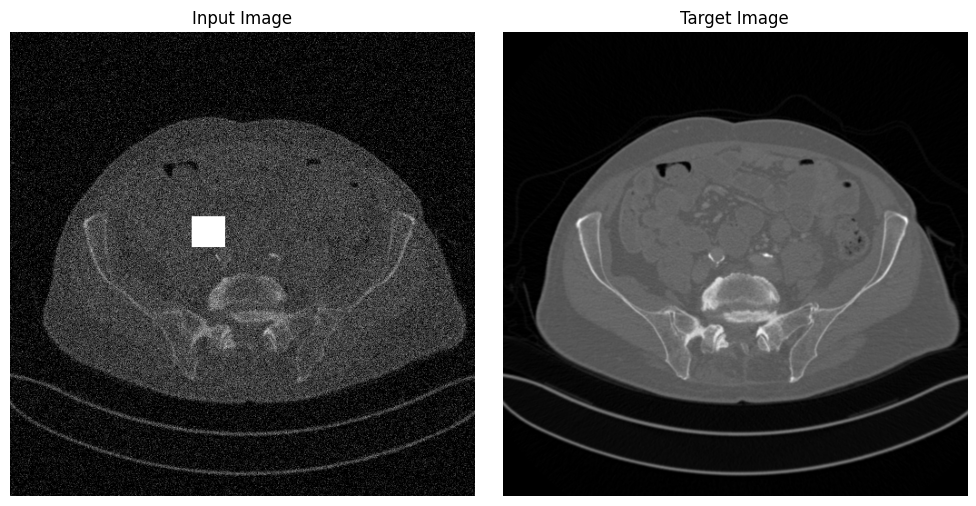

In [5]:
# visualiaztion of mayo CT dataset
import json
from pytorch_msssim import ssim, ms_ssim
from utils.metrics import compute_psnr
from piq import fsim, gmsd
import lpips
import torch
from torchvision import transforms

with open('../config/train.json', 'r') as f:
    config = json.load(f)
config['data_choices'][config['selected_data']] = os.path.abspath(os.path.join('..', config['data_choices'][config['selected_data']]))

transform = transforms.Compose([
    transforms.ToTensor(),
])

image, target = next(iter(get_dataloader(config, transform=transform)))
print(f"Image shape: {image.shape}, Target shape: {target.shape}")

# cheking the nosie level between input and output
ssim_val = ssim(image, target, data_range=1.0, size_average=False)
ms_ssim_val = ms_ssim(image, target, data_range=1.0, size_average=False)
fsim_score = fsim(image, target, data_range=1.0, chromatic = False)
gmsd_score = gmsd(image, target, data_range=1.0)
psnr_score = compute_psnr(image, target)
loss_fn = lpips.LPIPS(net='alex')  # or 'vgg' # best value 0, ~1 is very different 
image = image.to(torch.float32)
target = target.to(torch.float32)
image_ = image *2 -1
target_ = target*2-1
lp_score = loss_fn(image_, target_)
lp_score.item()
print(f"PSNR_SCORE:{psnr_score}")
print(f"SSIM_SCORE:{ssim_val}")
print(f"ms_SSIM SCORE: {ms_ssim_val}")
print(f"FSIM_SCORE: {fsim_score}")
print(f"GMSD_SCORE: {gmsd_score}")
print(f"LP_SCPRE: {lp_score.item()}")



print(image.shape)
image = image.squeeze()
target = target.squeeze()

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(image, cmap='gray')
ax[0].set_title('Input Image')
ax[0].axis('off')

ax[1].imshow(target, cmap='gray')
ax[1].set_title('Target Image')
ax[1].axis('off')
plt.tight_layout()
plt.show()





In [5]:
image.shape

torch.Size([512, 512])

In [8]:
image= np.load("/home/shiblu/Workspace/university/Masters_thesis/Masters-Thesis/medical_image_datasets/synthetic_added_noise/1mm B30/L067_input_000.npy")
target =np.load("/home/shiblu/Workspace/university/Masters_thesis/Masters-Thesis/medical_image_datasets/synthetic_added_noise/1mm B30/L067_target_088.npy")
image.dtype ,target.dtype

(dtype('float64'), dtype('float64'))